# Black-box allocation benchmark with quarterly PD and Basel IRB

This notebook implements the black-box decision benchmark for the quarterly-PD Basel IRB capital-allocation problem.

The black-box model is **not** a PD forecasting model. It maps predictors directly to an allocation:

```python
alpha_hat_{t+1} = f(x_t)
```

and is trained by maximising realised decision utility, equivalently minimising:

```python
loss = -mean(U(alpha_hat; c_q_realised, pd_a_realised))
```

The realised quarterly PD and annualised PD are constructed only to evaluate the decision objective and oracle benchmark. They are not model outputs, and no PD MSE loss or PTO optimisation layer is used.

The feature set includes the observed lagged quarterly charge-off rate `c_q_lag1 = c_{q,t-1}`. It deliberately does **not** include a PD lag, because PD here is constructed from charge-offs for target/evaluation conventions rather than observed as a ground-truth model signal.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the black-box linear and MLP models. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data" / "processed" / "fred_loan_return_aligned.csv").exists():
    ROOT = ROOT.parent

FIGURES_DIR = ROOT / "figures" / "blackbox_pd_irb"
RESULTS_DIR = ROOT / "models" / "notebooks" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Figures: figures/blackbox_pd_irb
Results: models/notebooks/results


## Configuration

The raw charge-off rate is annualised. It is converted to a quarterly charge-off rate before modelling, training, evaluation, or plotting. Set `CHARGE_OFF_CONVERSION = "simple"` only if you want the explicit divide-by-four convention.

The black-box model emits a continuous allocation in `[0, 1]`. To keep oracle regret meaningful, the oracle grid is deliberately much finer than the coarse 101-point PTO decision grid; otherwise a continuous black-box allocation can fall between grid points and appear to beat a coarse-grid oracle.

In [2]:
# Data conventions
CHARGE_OFF_IS_PERCENT = True
CHARGE_OFF_CONVERSION = "compound"  # alternatives: "simple"
HORIZON = 1
DATE_COL = "DATE"
TARGET_COL = "charge_off_rate"

# Decision and Basel constants
LGD = 0.45
M = 2.5
K1 = 1.0
LEVERAGE = 10.0
Y_BAR = 0.0168
LAMBDA = 10.0

PD_Q_CLIP_LOW = 1e-6
PD_Q_CLIP_HIGH = 0.99
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99
ORACLE_GRID_SIZE = 10001
ALPHA_GRID = np.linspace(0.0, 1.0, ORACLE_GRID_SIZE)

@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 16
    epochs: int = 500
    patience: int = 75
    val_frac: float = 0.2
    seed: int = 42

MODEL_CFG = ModelConfig()
INITIAL_TRAIN_FRAC = 0.75

## Quarterly charge-offs, annual PD, Basel IRB, and utility

In [3]:
def annual_chargeoff_to_quarterly(c_annual, conversion=CHARGE_OFF_CONVERSION):
    c_annual = np.asarray(c_annual, dtype=float)
    if conversion == "compound":
        return 1.0 - np.power(1.0 - c_annual, 1.0 / 4.0)
    if conversion == "simple":
        return c_annual / 4.0
    raise ValueError("CHARGE_OFF_CONVERSION must be 'compound' or 'simple'.")


def clip_pd_q(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


def clip_pd_a(pd_a):
    return np.clip(np.asarray(pd_a, dtype=float), PD_A_CLIP_LOW, PD_A_CLIP_HIGH)


def quarterly_pd_to_annual(pd_q):
    pd_q = clip_pd_q(pd_q)
    return clip_pd_a(1.0 - np.power(1.0 - pd_q, 4.0))


def k_irb_from_annual_pd(pd_a, lgd=LGD, m=M):
    # Input must be annual PD. Do not pass quarterly PD here.
    pd_a = clip_pd_a(pd_a)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    r = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
    b = np.square(0.11852 - 0.05478 * np.log(pd_a))
    maturity_adj = (1.0 + (m - 2.5) * b) / (1.0 - 1.5 * b)
    z = norm.ppf(pd_a) / np.sqrt(1.0 - r) + np.sqrt(r / (1.0 - r)) * norm.ppf(0.999)
    k_irb = lgd * (norm.cdf(z) - pd_a) * maturity_adj
    return np.maximum(k_irb, 0.0)


def utility_numpy(alpha, c_q, pd_a, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1):
    alpha = np.asarray(alpha, dtype=float)
    c_q = float(c_q)
    pd_a = float(clip_pd_a(pd_a))
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - c_q)
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = k_irb_from_annual_pd(pd_a) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def utility_torch_from_kirb(alpha, c_q, k_irb):
    # c_q and k_irb are realised fixed inputs. Gradients flow through alpha.
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k_irb * exposure
    shortfall = torch.relu(required_capital - available_buffer)
    return terminal_capital - LAMBDA * shortfall


def decision_components(alpha, c_q, pd_a):
    alpha = float(np.clip(alpha, 0.0, 1.0))
    c_q = float(c_q)
    pd_a = float(clip_pd_a(pd_a))
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    k_irb = float(k_irb_from_annual_pd(pd_a))
    required_capital = k_irb * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return {
        "exposure": exposure,
        "terminal_capital": terminal_capital,
        "committed_capital": committed_capital,
        "available_buffer": available_buffer,
        "required_capital": required_capital,
        "shortfall": shortfall,
        "utility": utility,
        "k_irb": k_irb,
    }


def optimise_alpha_grid(c_q, pd_a, alpha_grid=ALPHA_GRID):
    utilities = utility_numpy(alpha_grid, c_q=c_q, pd_a=pd_a)
    best_idx = int(np.argmax(utilities))
    return float(alpha_grid[best_idx]), float(utilities[best_idx])

## Load and align data

Each row uses predictors at date `t`, including observed `c_q_lag1`, to choose an allocation for the next quarter. Realised next-quarter `c_q` and annualised `pd_a` are used in the decision loss and evaluation.

In [4]:
def load_blackbox_panel(macro_csv, chargeoff_csv, date_col=DATE_COL, target_col=TARGET_COL, feature_cols=None, horizon=HORIZON):
    macro = pd.read_csv(macro_csv)
    charge = pd.read_csv(chargeoff_csv)
    macro[date_col] = pd.to_datetime(macro[date_col]).dt.to_period("Q").dt.start_time
    charge[date_col] = pd.to_datetime(charge[date_col]).dt.to_period("Q").dt.start_time

    if target_col not in charge.columns:
        raise ValueError(f"{target_col!r} not found in charge-off columns: {list(charge.columns)}")

    charge["c_annual_raw"] = pd.to_numeric(charge[target_col], errors="coerce")
    charge["c_annual_decimal"] = charge["c_annual_raw"] / 100.0 if CHARGE_OFF_IS_PERCENT else charge["c_annual_raw"]
    charge["c_q"] = annual_chargeoff_to_quarterly(charge["c_annual_decimal"].to_numpy())
    charge["pd_q"] = clip_pd_q(charge["c_q"].to_numpy() / LGD)
    charge["pd_a"] = quarterly_pd_to_annual(charge["pd_q"].to_numpy())

    keep_charge = [date_col, "c_annual_raw", "c_annual_decimal", "c_q", "pd_q", "pd_a"]
    df = pd.merge(macro, charge[keep_charge], on=date_col, how="inner").sort_values(date_col).reset_index(drop=True)

    # Observed autoregressive signal only. No PD lag is added as a model feature.
    df["c_q_lag1"] = df["c_q"].shift(1)

    df["target_date"] = df[date_col].shift(-horizon)
    df["c_annual_raw_next"] = df["c_annual_raw"].shift(-horizon)
    df["c_q_realised"] = df["c_q"].shift(-horizon)
    df["pd_q_realised"] = df["pd_q"].shift(-horizon)
    df["pd_a_realised"] = df["pd_a"].shift(-horizon)
    df["k_irb_realised"] = k_irb_from_annual_pd(df["pd_a_realised"].to_numpy())

    df["alpha_oracle"] = np.nan
    df["utility_oracle"] = np.nan
    for idx, row in df.dropna(subset=["c_q_realised", "pd_a_realised"]).iterrows():
        alpha_oracle, utility_oracle = optimise_alpha_grid(row["c_q_realised"], row["pd_a_realised"])
        df.loc[idx, "alpha_oracle"] = alpha_oracle
        df.loc[idx, "utility_oracle"] = utility_oracle

    if feature_cols is None:
        exclude = {
            date_col,
            "c_annual_raw", "c_annual_decimal", "c_q", "pd_q", "pd_a",
            "target_date", "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised",
            "k_irb_realised", "alpha_oracle", "utility_oracle",
        }
        feature_cols = [c for c in df.columns if c not in exclude]
    else:
        feature_cols = list(feature_cols)

    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    required = feature_cols + [
        "target_date", "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised",
        "k_irb_realised", "alpha_oracle", "utility_oracle",
    ]
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 30:
        raise ValueError(f"Only {len(df)} usable observations after alignment; check dates and missing values.")

    df.attrs["feature_cols"] = feature_cols
    return df

macro_csv = ROOT / "data" / "processed" / "macro_panel_quarterly.csv"
chargeoff_csv = ROOT / "data" / "processed" / "fred_loan_return_aligned.csv"
df = load_blackbox_panel(macro_csv, chargeoff_csv)
feature_cols = df.attrs["feature_cols"]

print(f"Observations after alignment and one-step decision target: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Decision date range: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
assert "c_q_lag1" in feature_cols
assert not any(col.startswith("pd_q_lag") or col.startswith("pd_a_lag") for col in feature_cols)
print("Lag feature included: c_q_lag1; PD lags excluded.")
display(df.head())

Observations after alignment and one-step decision target: 142
Feature date range: 1990-07-01 to 2025-10-01
Decision date range: 1990-10-01 to 2026-01-01
Features (13): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium', 'c_q_lag1']
Lag feature included: c_q_lag1; PD lags excluded.


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,...,pd_a,c_q_lag1,target_date,c_annual_raw_next,c_q_realised,pd_q_realised,pd_a_realised,k_irb_realised,alpha_oracle,utility_oracle
0,1990-07-01,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,...,0.028277,0.003594,1990-10-01,1.30,0.003266,0.007258,0.028716,0.101513,0.5319,1.071988
1,1990-10-01,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,...,0.028716,0.003215,1991-01-01,1.48,0.003721,0.008268,0.032665,0.105233,0.5204,1.068065
2,1991-01-01,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,...,0.032665,0.003266,1991-04-01,1.86,0.004683,0.010406,0.040980,0.112490,0.4990,1.060465
3,1991-04-01,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,...,0.040980,0.003721,1991-07-01,1.97,0.004962,0.011026,0.043381,0.114495,0.4934,1.058410
4,1991-07-01,2.0,6.866667,1.390822,0.383417,0.759342,0.195457,5.643333,1.428906,16.634219,...,0.043381,0.004683,1991-10-01,1.83,0.004607,0.010237,0.040324,0.111937,0.5006,1.061039


## Black-box allocation models

Both models output `alpha_hat` through a sigmoid head. The output-bias initialisation uses the mean oracle allocation in the current training window only as a starting point. Training still uses the realised decision loss, not MSE against oracle alpha.

In [5]:
class BlackBoxAllocator(nn.Module):
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1),
            )
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return torch.sigmoid(self.net(x)).squeeze(-1)


def init_output_bias_for_target(model, y_train):
    """Initialise sigmoid output bias to logit(mean oracle allocation)."""
    y_mean = float(np.clip(np.mean(y_train), 1e-6, 1.0 - 1e-6))
    logit_mean = np.log(y_mean / (1.0 - y_mean))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_blackbox_model(x_train, c_q_train, pd_a_train, alpha_oracle_train, model_type, model_cfg, return_history=False):
    torch.manual_seed(model_cfg.seed)
    np.random.seed(model_cfg.seed)

    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    c_tr, c_val = c_q_train[:train_size], c_q_train[train_size:]
    pd_a_tr, pd_a_val = pd_a_train[:train_size], pd_a_train[train_size:]
    alpha_oracle_tr, alpha_oracle_val = alpha_oracle_train[:train_size], alpha_oracle_train[train_size:]
    k_tr = k_irb_from_annual_pd(pd_a_tr)
    k_val = k_irb_from_annual_pd(pd_a_val)

    train_ds = TensorDataset(
        torch.tensor(x_tr, dtype=torch.float32),
        torch.tensor(c_tr, dtype=torch.float32),
        torch.tensor(k_tr, dtype=torch.float32),
    )
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=False)

    model = BlackBoxAllocator(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_target(model, alpha_oracle_train)
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)

    x_val_t = torch.tensor(x_val, dtype=torch.float32)
    c_val_t = torch.tensor(c_val, dtype=torch.float32)
    k_val_t = torch.tensor(k_val, dtype=torch.float32)

    oracle_utility_val = np.array([
        utility_numpy(a, c, p) for a, c, p in zip(alpha_oracle_val, c_val, pd_a_val)
    ], dtype=float)

    best_state = None
    best_val = float("inf")
    stale_epochs = 0
    history = []

    for epoch in range(model_cfg.epochs):
        model.train()
        train_losses = []
        train_utilities = []
        for xb, cb, kb in train_loader:
            optimiser.zero_grad()
            alpha_hat = model(xb)
            utility = utility_torch_from_kirb(alpha_hat, cb, kb)
            loss = -utility.mean()
            loss.backward()
            optimiser.step()
            train_losses.append(float(loss.item()))
            train_utilities.append(float(utility.mean().item()))

        model.eval()
        with torch.no_grad():
            alpha_val = model(x_val_t)
            utility_val_t = utility_torch_from_kirb(alpha_val, c_val_t, k_val_t)
            val_loss = float((-utility_val_t.mean()).item())
            alpha_val_np = np.clip(alpha_val.detach().cpu().numpy(), 0.0, 1.0)
            utility_val_np = utility_val_t.detach().cpu().numpy()

        val_regret = oracle_utility_val - utility_val_np
        history.append({
            "epoch": epoch + 1,
            "model": model_type,
            "train_loss": float(np.mean(train_losses)),
            "train_mean_utility": float(np.mean(train_utilities)),
            "val_loss": val_loss,
            "val_mean_utility": float(np.mean(utility_val_np)),
            "val_mean_regret": float(np.mean(val_regret)),
            "val_median_regret": float(np.median(val_regret)),
            "val_max_regret": float(np.max(val_regret)),
            "val_mean_alpha_hat": float(np.mean(alpha_val_np)),
            "val_mean_alpha_oracle": float(np.mean(alpha_oracle_val)),
        })

        if val_loss < best_val - 1e-12:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_alpha(model, x):
    model.eval()
    with torch.no_grad():
        alpha = model(torch.tensor(x, dtype=torch.float32)).detach().cpu().numpy()
    return np.clip(alpha, 0.0, 1.0)

## Expanding-window evaluation

In [6]:
def build_result_row(base_row, alpha_hat, model_name):
    alpha_hat = float(np.clip(alpha_hat, 0.0, 1.0))
    c_q_realised = float(base_row["c_q_realised"])
    pd_q_realised = float(base_row["pd_q_realised"])
    pd_a_realised = float(base_row["pd_a_realised"])
    alpha_oracle = float(base_row["alpha_oracle"])

    oracle_components = decision_components(alpha_oracle, c_q_realised, pd_a_realised)
    model_components = decision_components(alpha_hat, c_q_realised, pd_a_realised)
    regret = oracle_components["utility"] - model_components["utility"]

    return {
        "model": model_name,
        "date": pd.to_datetime(base_row["target_date"]),
        "feature_date": pd.to_datetime(base_row[DATE_COL]),
        "c_annual_raw": float(base_row["c_annual_raw_next"]),
        "c_q_lag1": float(base_row["c_q_lag1"]),
        "c_q_realised": c_q_realised,
        "pd_q_realised": pd_q_realised,
        "pd_a_realised": pd_a_realised,
        "k_irb_realised": oracle_components["k_irb"],
        "alpha_oracle": alpha_oracle,
        "alpha_hat": alpha_hat,
        "utility_oracle": oracle_components["utility"],
        "utility": model_components["utility"],
        "regret": regret,
        "shortfall_oracle": oracle_components["shortfall"],
        "shortfall": model_components["shortfall"],
        "terminal_capital_oracle": oracle_components["terminal_capital"],
        "terminal_capital": model_components["terminal_capital"],
        "available_buffer_oracle": oracle_components["available_buffer"],
        "available_buffer": model_components["available_buffer"],
        "required_capital_oracle": oracle_components["required_capital"],
        "required_capital": model_components["required_capital"],
    }


def run_expanding_window_blackbox(df, feature_cols, initial_train_frac=INITIAL_TRAIN_FRAC, model_cfg=MODEL_CFG, return_history=True):
    first_test_idx = int(np.floor(len(df) * initial_train_frac))
    if first_test_idx < 20 or len(df) - first_test_idx < 5:
        raise ValueError("Not enough observations for expanding-window evaluation.")

    records = []
    histories = []
    total = len(df) - first_test_idx
    print(f"Initial train observations: {first_test_idx} | Expanding-window test observations: {total}")

    for step, test_idx in enumerate(range(first_test_idx, len(df)), start=1):
        train_df = df.iloc[:test_idx].copy()
        test_row = df.iloc[test_idx]

        scaler = StandardScaler()
        x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))
        c_q_train = train_df["c_q_realised"].to_numpy(dtype=float)
        pd_a_train = train_df["pd_a_realised"].to_numpy(dtype=float)
        alpha_oracle_train = train_df["alpha_oracle"].to_numpy(dtype=float)

        for model_name in ["linear", "mlp"]:
            step_cfg = ModelConfig(
                hidden_dim=model_cfg.hidden_dim,
                lr=model_cfg.lr,
                weight_decay=model_cfg.weight_decay,
                batch_size=model_cfg.batch_size,
                epochs=model_cfg.epochs,
                patience=model_cfg.patience,
                val_frac=model_cfg.val_frac,
                seed=model_cfg.seed + step,
            )
            model, hist = train_blackbox_model(
                x_train=x_train,
                c_q_train=c_q_train,
                pd_a_train=pd_a_train,
                alpha_oracle_train=alpha_oracle_train,
                model_type=model_name,
                model_cfg=step_cfg,
                return_history=True,
            )
            alpha_hat = float(predict_alpha(model, x_test)[0])
            records.append(build_result_row(test_row, alpha_hat, model_name))

            if return_history:
                hist = hist.copy()
                hist["test_date"] = pd.to_datetime(test_row["target_date"])
                hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                histories.append(hist)

        if step == 1 or step == total or step % 5 == 0:
            print(f"Completed {step}/{total} expanding windows")

    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history

pred_long, training_history = run_expanding_window_blackbox(df, feature_cols)
display(pred_long.head())

Initial train observations: 106 | Expanding-window test observations: 36
Completed 1/36 expanding windows
Completed 5/36 expanding windows
Completed 10/36 expanding windows
Completed 15/36 expanding windows
Completed 20/36 expanding windows
Completed 25/36 expanding windows
Completed 30/36 expanding windows
Completed 35/36 expanding windows
Completed 36/36 expanding windows


,model,date,feature_date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,k_irb_realised,alpha_oracle,...,utility,regret,shortfall_oracle,shortfall,terminal_capital_oracle,terminal_capital,available_buffer_oracle,available_buffer,required_capital_oracle,required_capital
0,linear,2017-04-01,2017-01-01,0.37,0.001027,0.000926,0.002058,0.008208,0.068614,0.6547,...,1.101653,0.002273,0.0,0.0,1.103925,1.101653,0.449225,0.461270,0.449216,0.439392
1,mlp,2017-04-01,2017-01-01,0.37,0.001027,0.000926,0.002058,0.008208,0.068614,0.6547,...,1.098641,0.005284,0.0,0.0,1.103925,1.098641,0.449225,0.477230,0.449216,0.426375
2,linear,2017-07-01,2017-04-01,0.34,0.000851,0.000851,0.001891,0.007544,0.066376,0.6647,...,1.102315,0.003697,0.0,0.0,1.106012,1.102315,0.441312,0.460796,0.441204,0.425817
3,mlp,2017-07-01,2017-04-01,0.34,0.000851,0.000851,0.001891,0.007544,0.066376,0.6647,...,1.102623,0.003389,0.0,0.0,1.106012,1.102623,0.441312,0.459174,0.441204,0.427099
4,linear,2017-10-01,2017-07-01,0.36,0.000926,0.000901,0.002003,0.007987,0.067888,0.6579,...,1.091974,0.012624,0.0,0.0,1.104598,1.091974,0.446698,0.513476,0.446637,0.392733


## Result collection

In [7]:
base_cols = [
    "date", "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised",
    "k_irb_realised", "alpha_oracle", "utility_oracle", "shortfall_oracle",
    "terminal_capital_oracle", "available_buffer_oracle", "required_capital_oracle",
]
wide_metrics = [
    "alpha_hat", "utility", "regret", "shortfall", "terminal_capital", "available_buffer", "required_capital",
]
wide = pred_long.pivot(index="date", columns="model", values=wide_metrics).sort_index()
wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
wide = wide.reset_index()
base = pred_long[pred_long["model"] == "linear"][base_cols].copy()
results = base.merge(wide, on="date", how="left")

results = results[[
    "date",
    "c_annual_raw",
    "c_q_lag1",
    "c_q_realised",
    "pd_q_realised",
    "pd_a_realised",
    "k_irb_realised",
    "alpha_oracle",
    "alpha_hat_linear",
    "alpha_hat_mlp",
    "utility_oracle",
    "utility_linear",
    "utility_mlp",
    "regret_linear",
    "regret_mlp",
    "shortfall_oracle",
    "shortfall_linear",
    "shortfall_mlp",
    "terminal_capital_oracle",
    "terminal_capital_linear",
    "terminal_capital_mlp",
    "available_buffer_oracle",
    "available_buffer_linear",
    "available_buffer_mlp",
    "required_capital_oracle",
    "required_capital_linear",
    "required_capital_mlp",
]]

output_csv = RESULTS_DIR / "blackbox_quarterly_pd_irb_predictions.csv"
results.to_csv(output_csv, index=False)
print(f"Saved results to {output_csv.relative_to(ROOT)}")
display(results.head())

Saved results to models/notebooks/results/blackbox_quarterly_pd_irb_predictions.csv


,date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,k_irb_realised,alpha_oracle,alpha_hat_linear,alpha_hat_mlp,...,shortfall_mlp,terminal_capital_oracle,terminal_capital_linear,terminal_capital_mlp,available_buffer_oracle,available_buffer_linear,available_buffer_mlp,required_capital_oracle,required_capital_linear,required_capital_mlp
0,2017-04-01,0.37,0.001027,0.000926,0.002058,0.008208,0.068614,0.6547,0.640383,0.621411,...,0.0,1.103925,1.101653,1.098641,0.449225,0.461270,0.477230,0.449216,0.439392,0.426375
1,2017-07-01,0.34,0.000851,0.000851,0.001891,0.007544,0.066376,0.6647,0.641519,0.643450,...,0.0,1.106012,1.102315,1.102623,0.441312,0.460796,0.459174,0.441204,0.425817,0.427099
2,2017-10-01,0.36,0.000926,0.000901,0.002003,0.007987,0.067888,0.6579,0.578498,0.601932,...,0.0,1.104598,1.091974,1.095700,0.446698,0.513476,0.493768,0.446637,0.392733,0.408641
3,2018-01-01,0.30,0.000851,0.000751,0.001669,0.006657,0.063081,0.6801,0.684626,0.637046,...,0.0,1.109150,1.109877,1.102240,0.429050,0.425250,0.465195,0.429013,0.431868,0.401854
4,2018-04-01,0.27,0.000901,0.000676,0.001502,0.005993,0.060333,0.6934,0.632431,0.651498,...,0.0,1.111806,1.101975,1.105050,0.418406,0.469544,0.453552,0.418348,0.381563,0.393067


## Diagnostics and sanity checks

In [8]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

# 1. Raw annual charge-offs are converted before modelling/evaluation.
assert np.allclose(results["pd_q_realised"], clip_pd_q(results["c_q_realised"] / LGD))
print(f"Charge-off conversion: {CHARGE_OFF_CONVERSION!r}; percent input: {CHARGE_OFF_IS_PERCENT}")
display(results[["c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised"]].head())

# 2-4. Realised PD and K_IRB checks.
pd_q_cols = ["pd_q_realised"]
pd_a_cols = ["pd_a_realised"]
k_cols = ["k_irb_realised"]
assert np.isfinite(results[pd_q_cols].to_numpy()).all()
assert ((results[pd_q_cols] > 0.0) & (results[pd_q_cols] < 1.0)).all().all()
assert np.isfinite(results[pd_a_cols].to_numpy()).all()
assert ((results[pd_a_cols] > 0.0) & (results[pd_a_cols] < 1.0)).all().all()
assert np.isfinite(results[k_cols].to_numpy()).all()
assert (results[k_cols] >= 0.0).all().all()

# 5. Basel IRB receives annual PD, generated from quarterly PD.
assert np.allclose(results["pd_a_realised"], quarterly_pd_to_annual(results["pd_q_realised"]), atol=1e-12)
print("IRB check passed: k_irb_from_annual_pd is called on realised annualised PD.")

# 6. Black-box outputs are allocations in [0, 1].
alpha_cols = ["alpha_hat_linear", "alpha_hat_mlp"]
assert np.isfinite(results[alpha_cols].to_numpy()).all()
assert ((results[alpha_cols] >= 0.0) & (results[alpha_cols] <= 1.0)).all().all()

# 7. Regret should be non-negative up to numerical tolerance.
min_regret = results[["regret_linear", "regret_mlp"]].min().min()
if min_regret < -1e-8:
    raise AssertionError(f"Meaningfully negative regret found: {min_regret}")
print(f"Minimum regret: {min_regret:.3e}")

summary_cols = [
    "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised", "k_irb_realised",
    "alpha_oracle", "alpha_hat_linear", "alpha_hat_mlp",
    "utility_oracle", "utility_linear", "utility_mlp",
    "regret_linear", "regret_mlp",
    "shortfall_oracle", "shortfall_linear", "shortfall_mlp",
]
display(describe_columns(results, summary_cols))

bind_summary = pd.DataFrame({
    "oracle": results["shortfall_oracle"] > 1e-12,
    "linear": results["shortfall_linear"] > 1e-12,
    "mlp": results["shortfall_mlp"] > 1e-12,
}).mean().rename("bind_share").to_frame()
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
print(f"Oracle grid size: {ORACLE_GRID_SIZE}")
display(bind_summary)

Charge-off conversion: 'compound'; percent input: True


,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised
0,0.37,0.001027,0.000926,0.002058
1,0.34,0.000851,0.000851,0.001891
2,0.36,0.000926,0.000901,0.002003
3,0.30,0.000851,0.000751,0.001669
4,0.27,0.000901,0.000676,0.001502


IRB check passed: k_irb_from_annual_pd is called on realised annualised PD.
Minimum regret: 5.789e-04


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_annual_raw,36.0,0.369722,0.147212,0.120000,0.135000,0.270000,0.360000,0.512500,0.582500,0.590000
c_q_lag1,36.0,0.000898,0.000347,0.000300,0.000338,0.000676,0.000876,0.001127,0.001416,0.001478
c_q_realised,36.0,0.000926,0.000369,0.000300,0.000338,0.000676,0.000901,0.001284,0.001459,0.001478
pd_q_realised,36.0,0.002057,0.000820,0.000667,0.000750,0.001502,0.002003,0.002853,0.003243,0.003285
pd_a_realised,36.0,0.008200,0.003260,0.002665,0.002998,0.005993,0.007987,0.011362,0.012910,0.013076
k_irb_realised,36.0,0.066343,0.011860,0.040927,0.043458,0.060333,0.067888,0.077226,0.080575,0.080909
alpha_oracle,36.0,0.669089,0.057849,0.603900,0.605175,0.618375,0.657900,0.693400,0.787475,0.803600
alpha_hat_linear,36.0,0.619593,0.052719,0.453950,0.531938,0.591534,0.630298,0.651762,0.684741,0.721202
alpha_hat_mlp,36.0,0.601600,0.026921,0.551917,0.561889,0.586274,0.598918,0.625153,0.644372,0.651498
utility_oracle,36.0,1.106412,0.011681,1.092528,1.092837,1.095949,1.104598,1.111806,1.129639,1.132593


Decision constants: LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0
Oracle grid size: 10001


,bind_share
oracle,0.000000
linear,0.111111
mlp,0.055556


## Plots

In [9]:
plt.rcdefaults()
plt.rcParams.update({
    "font.size": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "font.sans-serif": ["DejaVu Sans"],
})

MODEL_COLORS = {"linear": "#2166ac", "mlp": "#d6604d"}
ORACLE_COLOR = "#1a1a1a"
REAL_COLOR = "#333333"

plot_df = results.sort_values("date").copy()

def format_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)

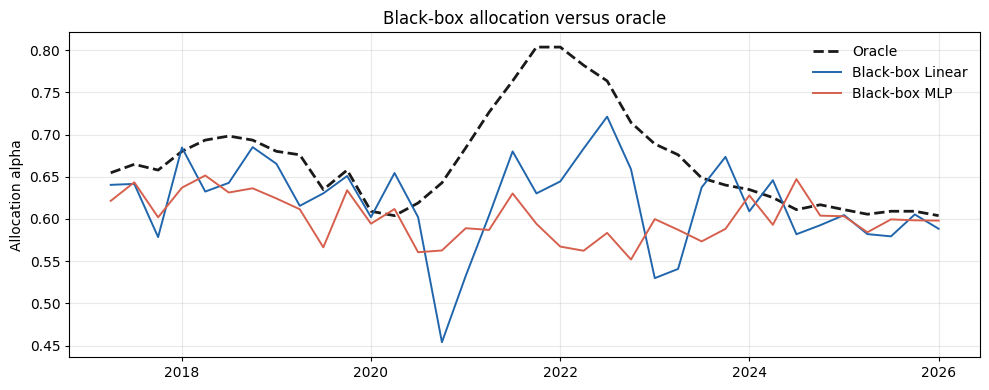

In [10]:
# 1. Allocation comparison
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
ax.plot(plot_df["date"], plot_df["alpha_hat_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Black-box Linear")
ax.plot(plot_df["date"], plot_df["alpha_hat_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="Black-box MLP")
ax.set_ylabel("Allocation alpha")
ax.set_title("Black-box allocation versus oracle")
format_date_axis(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "allocation_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

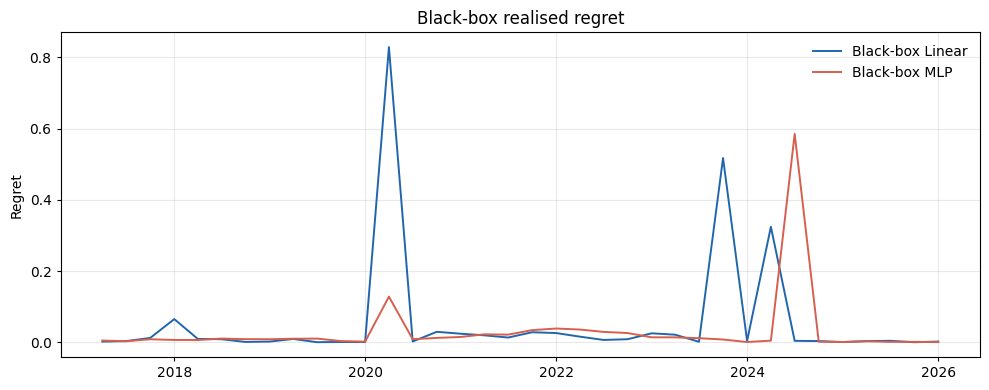

In [11]:
# 2. Regret over time
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["date"], plot_df["regret_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Black-box Linear")
ax.plot(plot_df["date"], plot_df["regret_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="Black-box MLP")
ax.set_ylabel("Regret")
ax.set_title("Black-box realised regret")
format_date_axis(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "regret.png", dpi=200, bbox_inches="tight")
plt.show()

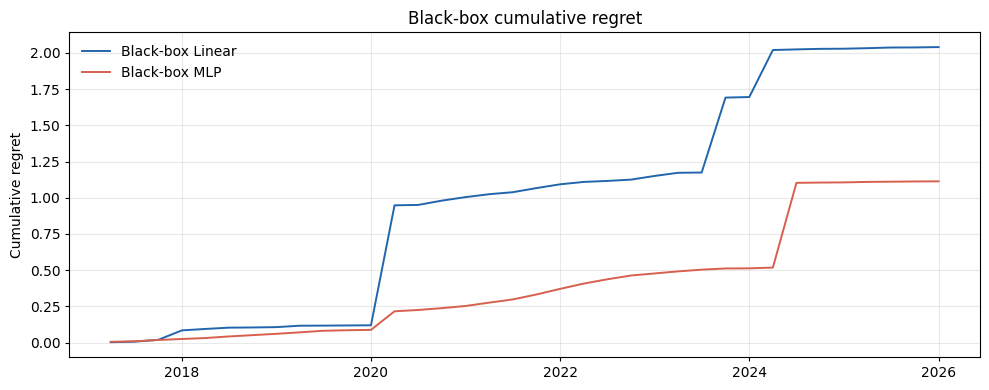

In [12]:
# 3. Cumulative regret
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["date"], plot_df["regret_linear"].cumsum(), color=MODEL_COLORS["linear"], lw=1.4, label="Black-box Linear")
ax.plot(plot_df["date"], plot_df["regret_mlp"].cumsum(), color=MODEL_COLORS["mlp"], lw=1.4, label="Black-box MLP")
ax.set_ylabel("Cumulative regret")
ax.set_title("Black-box cumulative regret")
format_date_axis(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cumulative_regret.png", dpi=200, bbox_inches="tight")
plt.show()

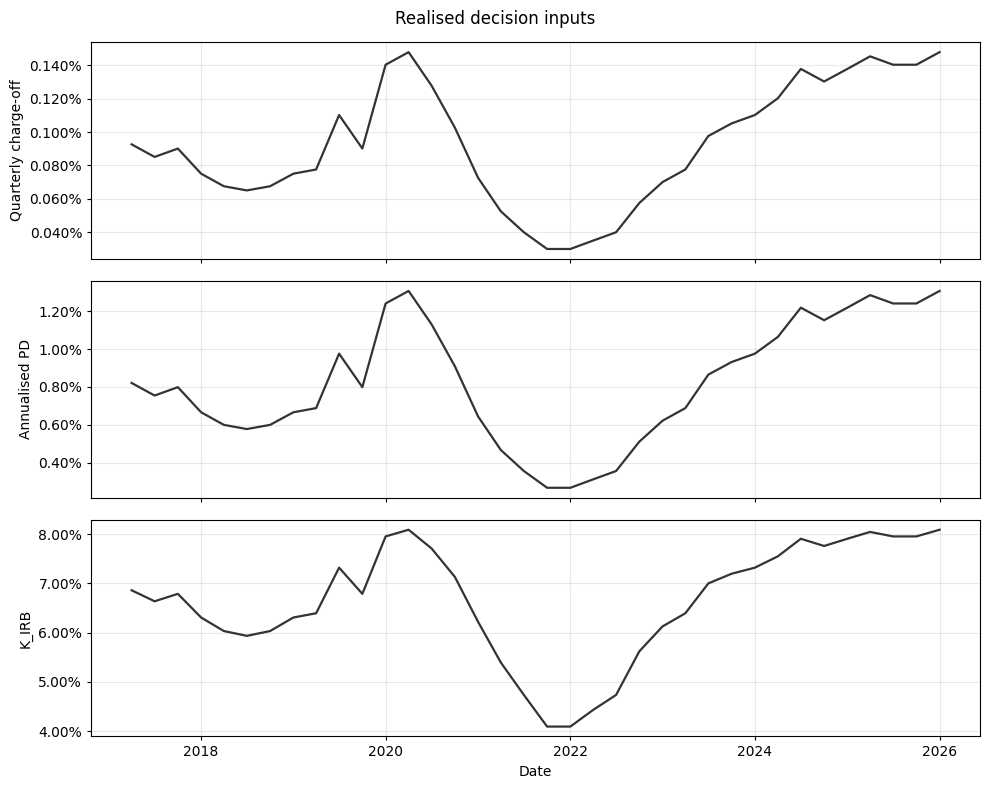

In [13]:
# 4. Realised inputs
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=1.6)
axes[0].set_ylabel("Quarterly charge-off")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].plot(plot_df["date"], plot_df["pd_a_realised"], color=REAL_COLOR, lw=1.6)
axes[1].set_ylabel("Annualised PD")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[2].plot(plot_df["date"], plot_df["k_irb_realised"], color=REAL_COLOR, lw=1.6)
axes[2].set_ylabel("K_IRB")
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[2].set_xlabel("Date")
for ax in axes:
    format_date_axis(ax)
fig.suptitle("Realised decision inputs")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "realised_inputs.png", dpi=200, bbox_inches="tight")
plt.show()

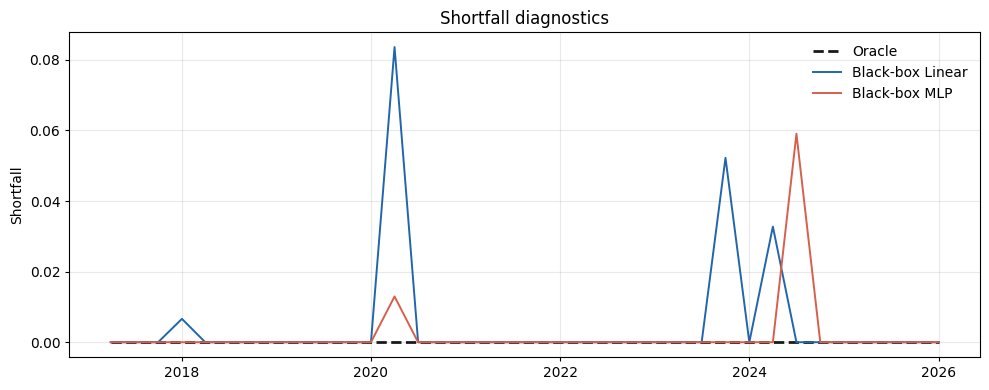

In [14]:
# 5. Shortfall diagnostics
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["date"], plot_df["shortfall_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
ax.plot(plot_df["date"], plot_df["shortfall_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Black-box Linear")
ax.plot(plot_df["date"], plot_df["shortfall_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="Black-box MLP")
ax.set_ylabel("Shortfall")
ax.set_title("Shortfall diagnostics")
format_date_axis(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shortfall_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()

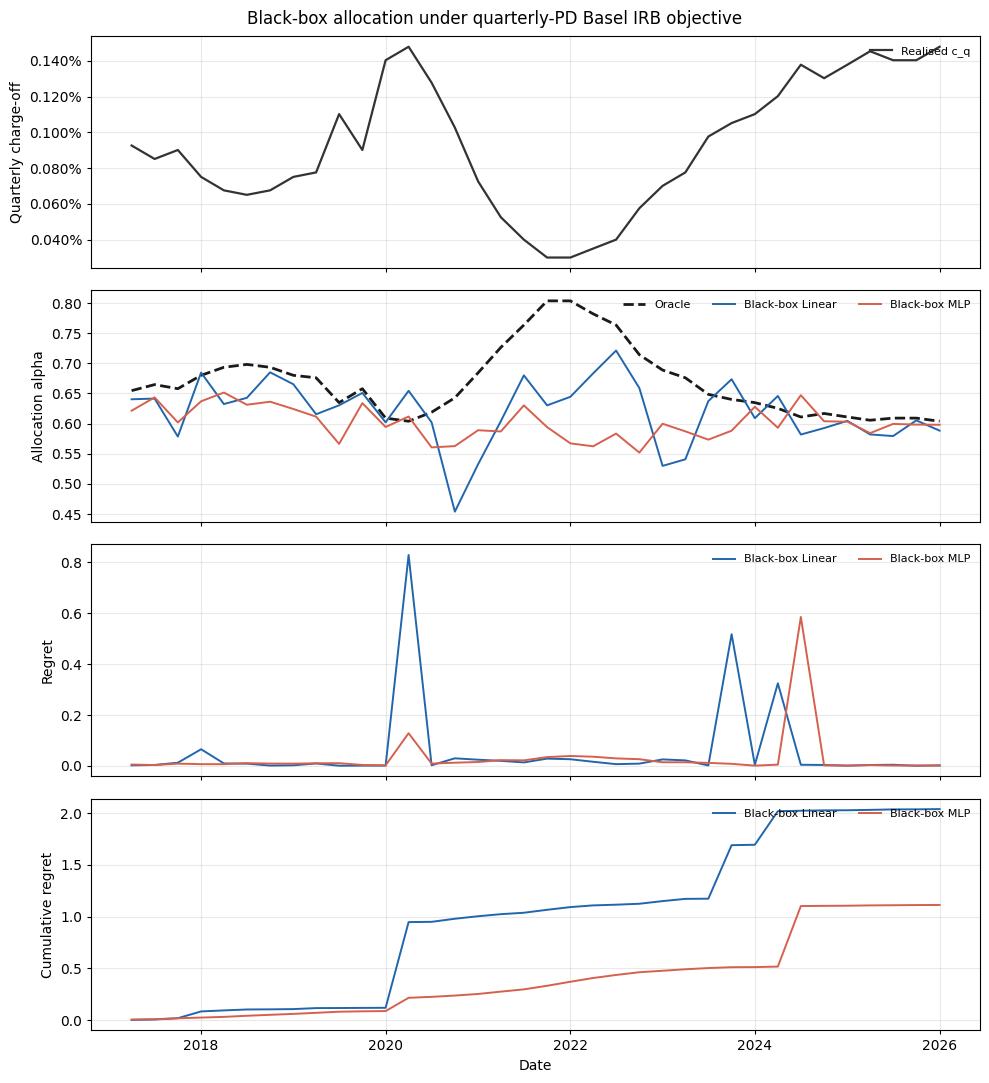

In [15]:
# 6. Compact thesis figure
fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
axes[0].plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=1.6, label="Realised c_q")
axes[0].set_ylabel("Quarterly charge-off")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

axes[1].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
axes[1].plot(plot_df["date"], plot_df["alpha_hat_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Black-box Linear")
axes[1].plot(plot_df["date"], plot_df["alpha_hat_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="Black-box MLP")
axes[1].set_ylabel("Allocation alpha")

axes[2].plot(plot_df["date"], plot_df["regret_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Black-box Linear")
axes[2].plot(plot_df["date"], plot_df["regret_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="Black-box MLP")
axes[2].set_ylabel("Regret")

axes[3].plot(plot_df["date"], plot_df["regret_linear"].cumsum(), color=MODEL_COLORS["linear"], lw=1.4, label="Black-box Linear")
axes[3].plot(plot_df["date"], plot_df["regret_mlp"].cumsum(), color=MODEL_COLORS["mlp"], lw=1.4, label="Black-box MLP")
axes[3].set_ylabel("Cumulative regret")
axes[3].set_xlabel("Date")

for ax in axes:
    format_date_axis(ax)
    ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=3)
fig.suptitle("Black-box allocation under quarterly-PD Basel IRB objective", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "blackbox_pd_irb_compact_panel.png", dpi=220, bbox_inches="tight")
plt.show()

## Learning curves

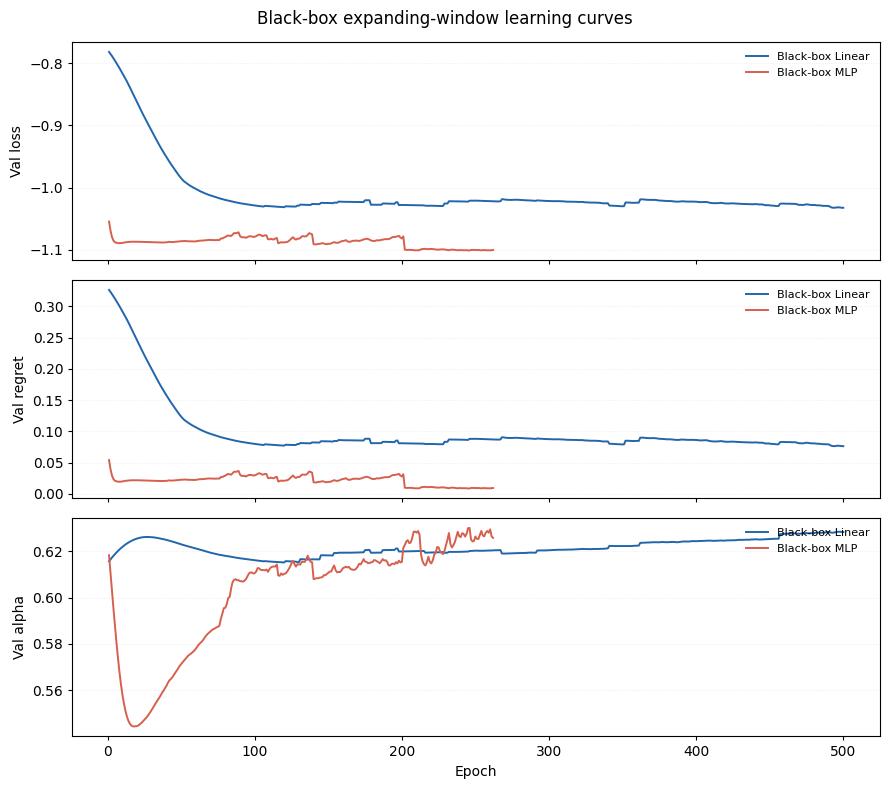

In [16]:
if not training_history.empty:
    mean_history = training_history.groupby(["model", "epoch"], as_index=False).agg(
        mean_val_loss=("val_loss", "mean"),
        mean_val_regret=("val_mean_regret", "mean"),
        mean_val_alpha=("val_mean_alpha_hat", "mean"),
    )

    fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
    for model_name, group in mean_history.groupby("model"):
        group = group.sort_values("epoch")
        color = MODEL_COLORS.get(model_name, "grey")
        label = "Black-box Linear" if model_name == "linear" else "Black-box MLP"
        axes[0].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
        axes[1].plot(group["epoch"], group["mean_val_regret"], color=color, lw=1.4, label=label)
        axes[2].plot(group["epoch"], group["mean_val_alpha"], color=color, lw=1.4, label=label)
    axes[0].set_ylabel("Val loss")
    axes[1].set_ylabel("Val regret")
    axes[2].set_ylabel("Val alpha")
    axes[2].set_xlabel("Epoch")
    for ax in axes:
        ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":")
        ax.legend(fontsize=8, frameon=False, loc="upper right")
    fig.suptitle("Black-box expanding-window learning curves")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "learning_curves.png", dpi=200, bbox_inches="tight")
    plt.show()